In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
dataset = pd.read_csv('../data/Ads_CTR_Optimisation.csv')

(10000, 10)

In [36]:
# Initialize variables

N = 10000 # total number of observations; todo-convert to dynamic var like in real world situation
d = 10 # number of total ads being tested

selection_history = []    # list that will house the history of ads selected in each round

cnt_selections = [0] * d  # list that will hold the running count of times each ad has been selected
sum_rewards = [0] * d  # list that will hold the run sum of rewards each ad has earned

reward_total = 0

In [37]:
for n in range(0,N):
    ad = 0
    max_upper_bound = 0
    for i in range(0, d):
        if (cnt_selections[i] == 0):
            ad = i
            break
        else:
            if n > 0:
                avg_reward = sum_rewards[i] / cnt_selections[i]
                ucb = avg_reward + math.sqrt(3/2 * math.log(n) / cnt_selections[i])
                if(ucb > max_upper_bound):
                    ad = i
                    max_upper_bound = ucb

    selection_history.append(ad)
    
    cnt_selections[ad] += 1
    sum_rewards[ad] += dataset.values[n, ad]
    reward_total += dataset.values[n, ad]
    
    new_avg_reward = sum_rewards[ad] / cnt_selections[ad]
    new_ucb = new_avg_reward + math.sqrt(3 / 2 * math.log(n+1) / cnt_selections[i])
    if(new_ucb > max_upper_bound):
        max_upper_bound = new_ucb

In [39]:
cnt_selections
sum_rewards

np.concatenate([[sum_rewards], [cnt_selections]])

array([[  74,   43,   25,   33, 1730,    1,   35,  229,   36,    5],
       [ 502,  364,  278,  317, 6434,  147,  326, 1130,  331,  171]])

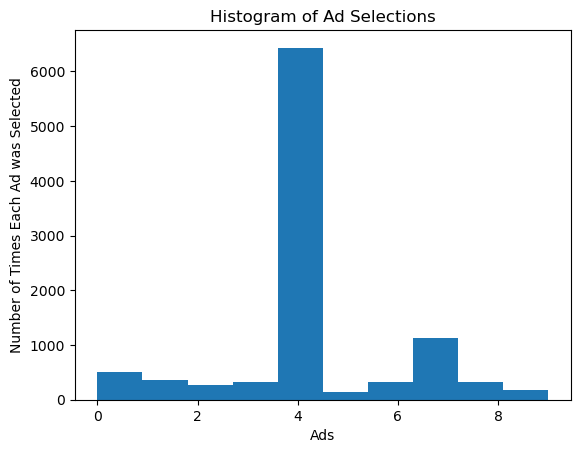

0.2211


In [40]:
plt.hist(selection_history)
plt.title('Histogram of Ad Selections')
plt.xlabel('Ads')
plt.ylabel('Number of Times Each Ad was Selected')
plt.show()

print(reward_total / len(selection_history))